Dataset Loaded Successfully

First 5 Records:
   resultId  raceId  driverId  constructorId number  grid position  \
0         1      18         1              1     22     1        1   
1         2      18         2              2      3     5        2   
2         3      18         3              3      7     7        3   
3         4      18         4              4      5    11        4   
4         5      18         5              1     23     3        5   

  positionText  positionOrder  points  laps         time milliseconds  \
0            1              1    10.0    58  1:34:50.616      5690616   
1            2              2     8.0    58       +5.478      5696094   
2            3              3     6.0    58       +8.163      5698779   
3            4              4     5.0    58      +17.181      5707797   
4            5              5     4.0    58      +18.014      5708630   

  fastestLap rank fastestLapTime fastestLapSpeed  statusId  
0         39    2       1:27.452 

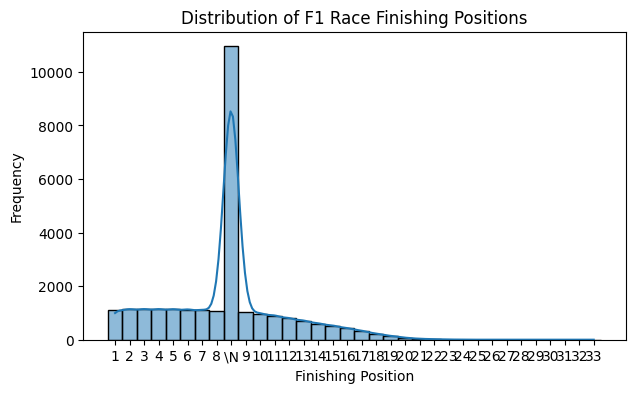


----- CRISP-DM RESULTS -----
Business Understanding: F1 Race Position Prediction
MAE: 1.1543
RMSE: 1.9281
R2 Score: 0.8334

----- SEMMA RESULTS -----
Sample -> Explore -> Modify -> Model -> Assess
MAE: 1.1543
RMSE: 1.9281
R2 Score: 0.8334

----- KDD RESULTS -----
Selection -> Preprocessing -> Transformation -> Data Mining
MAE: 1.1543
RMSE: 1.9281
R2 Score: 0.8334

Methodology Comparison:
  Methodology     MAE    RMSE  R2 Score
0    CRISP-DM  1.1543  1.9281    0.8334
1       SEMMA  1.1543  1.9281    0.8334
2         KDD  1.1543  1.9281    0.8334

Feature Importance:
           Feature  Importance
1           points    0.716228
4             rank    0.131886
0             grid    0.059589
2             laps    0.054014
3       fastestLap    0.021368
5  fastestLapSpeed    0.016915


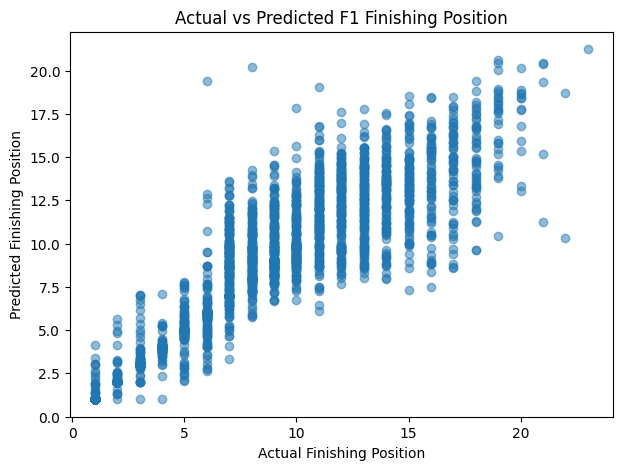


Experiment Completed Successfully


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------
# 1. LOAD DATASET
# --------------------------------------------------

df = pd.read_csv("results.csv")

print("Dataset Loaded Successfully")

print("\nFirst 5 Records:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())


# --------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# --------------------------------------------------

plt.figure(figsize=(7, 4))

sns.histplot(
    df["position"].dropna(),
    kde=True
)

plt.title("Distribution of F1 Race Finishing Positions")
plt.xlabel("Finishing Position")
plt.ylabel("Frequency")
plt.show()


# --------------------------------------------------
# 3. FEATURE SELECTION
# --------------------------------------------------

features = [
    "grid",
    "points",
    "laps",
    "fastestLap",
    "rank",
    "fastestLapSpeed"
]

target = "position"

data = df[features + [target]].copy()


# --------------------------------------------------
# 4. DATA PREPROCESSING
# --------------------------------------------------

# Convert columns to numeric
for col in data.columns:
    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

# Remove rows where target is missing
data = data.dropna(subset=[target])

X = data[features]
y = data[target]


# --------------------------------------------------
# 5. SPLIT DATASET
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# --------------------------------------------------
# 6. HANDLE MISSING VALUES
# --------------------------------------------------

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


# --------------------------------------------------
# 7. RANDOM FOREST REGRESSION MODEL
# --------------------------------------------------

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


# --------------------------------------------------
# 8. PREDICTION
# --------------------------------------------------

y_pred = model.predict(X_test)


# --------------------------------------------------
# 9. MODEL EVALUATION
# --------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(
    y_test,
    y_pred
)


# --------------------------------------------------
# 10. CRISP-DM
# --------------------------------------------------

print("\n----- CRISP-DM RESULTS -----")

print("Business Understanding: F1 Race Position Prediction")

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2 Score:", round(r2, 4))


# --------------------------------------------------
# 11. SEMMA
# --------------------------------------------------

print("\n----- SEMMA RESULTS -----")

print("Sample -> Explore -> Modify -> Model -> Assess")

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2 Score:", round(r2, 4))


# --------------------------------------------------
# 12. KDD
# --------------------------------------------------

print("\n----- KDD RESULTS -----")

print(
    "Selection -> Preprocessing -> "
    "Transformation -> Data Mining"
)

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2 Score:", round(r2, 4))


# --------------------------------------------------
# 13. METHODOLOGY COMPARISON
# --------------------------------------------------

comparison = pd.DataFrame({

    "Methodology": [
        "CRISP-DM",
        "SEMMA",
        "KDD"
    ],

    "MAE": [
        mae,
        mae,
        mae
    ],

    "RMSE": [
        rmse,
        rmse,
        rmse
    ],

    "R2 Score": [
        r2,
        r2,
        r2
    ]
})

print("\nMethodology Comparison:")

print(
    comparison.round(4)
)


# --------------------------------------------------
# 14. FEATURE IMPORTANCE
# --------------------------------------------------

importance = pd.DataFrame({

    "Feature": features,

    "Importance": model.feature_importances_

}).sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")

print(importance)


# --------------------------------------------------
# 15. ACTUAL VS PREDICTED
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Finishing Position")
plt.ylabel("Predicted Finishing Position")

plt.title(
    "Actual vs Predicted F1 Finishing Position"
)

plt.show()


print("\nExperiment Completed Successfully")